# Sorting: repeated passes, divide-and-conquer, and Python's sort

Compare bubble sort, merge sort, and Python's built-in sorted(). This notebook derives the growth bounds, counts comparisons and swaps, then compares recorded times with scaled Big O reference curves. The benchmark targets 10 seconds; together with the sum and Fibonacci experiments, the planned suite stays below two minutes.

In [1]:
def bubble_sort(values):
    result = list(values)
    comparisons = 0
    swaps = 0

    for end in range(len(result) - 1, 0, -1):
        swapped = False
        for index in range(end):
            comparisons += 1
            if result[index] > result[index + 1]:
                result[index], result[index + 1] = result[index + 1], result[index]
                swaps += 1
                swapped = True
        if not swapped:
            break

    return result, comparisons, swaps


def merge_sort(values):
    values = list(values)
    if len(values) <= 1:
        return values, 0

    middle = len(values) // 2
    left, left_comparisons = merge_sort(values[:middle])
    right, right_comparisons = merge_sort(values[middle:])

    merged = []
    left_index = 0
    right_index = 0
    comparisons = 0

    while left_index < len(left) and right_index < len(right):
        comparisons += 1
        if left[left_index] <= right[right_index]:
            merged.append(left[left_index])
            left_index += 1
        else:
            merged.append(right[right_index])
            right_index += 1

    merged.extend(left[left_index:])
    merged.extend(right[right_index:])
    total_comparisons = left_comparisons + right_comparisons + comparisons
    return merged, total_comparisons

## Check the sorters on small cases

Sorted, reversed, duplicate-heavy, and mixed inputs reveal different behavior. The return values should agree with Python's built-in result; the comparison and swap counts tell us how each implementation got there.

In [2]:
examples = {
    "already sorted": list(range(8)),
    "reverse order": list(range(7, -1, -1)),
    "duplicates": [3, 1, 3, 2, 1, 2, 0, 0],
    "mixed": [8, 3, 7, 4, 9, 2, 6, 5],
}

for label, values in examples.items():
    bubble_result, bubble_comparisons, bubble_swaps = bubble_sort(values)
    merge_result, merge_comparisons = merge_sort(values)
    builtin_result = sorted(values)

    if bubble_result != merge_result or merge_result != builtin_result:
        raise AssertionError(f"Sorting methods disagree for {label}")

    print({
        "input pattern": label,
        "sorted result": builtin_result,
        "bubble comparisons": bubble_comparisons,
        "bubble swaps": bubble_swaps,
        "merge comparisons": merge_comparisons,
    })

{'input pattern': 'already sorted', 'sorted result': [0, 1, 2, 3, 4, 5, 6, 7], 'bubble comparisons': 7, 'bubble swaps': 0, 'merge comparisons': 12}
{'input pattern': 'reverse order', 'sorted result': [0, 1, 2, 3, 4, 5, 6, 7], 'bubble comparisons': 28, 'bubble swaps': 28, 'merge comparisons': 12}
{'input pattern': 'duplicates', 'sorted result': [0, 0, 1, 1, 2, 2, 3, 3], 'bubble comparisons': 28, 'bubble swaps': 20, 'merge comparisons': 15}
{'input pattern': 'mixed', 'sorted result': [2, 3, 4, 5, 6, 7, 8, 9], 'bubble comparisons': 27, 'bubble swaps': 16, 'merge comparisons': 17}


## Derive the growth of each sorter

### Bubble sort: early-exit best case O(n), worst case O(n²)

For already sorted input, the first pass makes n - 1 comparisons and no swaps, then exits. So best-case time is Theta(n). In the worst case, the inner loop runs n - 1, n - 2, ..., 1 times. The sum is

(n - 1) + (n - 2) + ... + 1 = n(n - 1)/2.

That is a quadratic expression, so worst-case time is Theta(n²), hence O(n²). The reverse-order list realizes this comparison count and has n(n - 1)/2 inversions to swap. This implementation copies the input list, so its extra space is O(n); an in-place bubble sort would use O(1) extra space.

### Merge sort: O(n log n)

At each level, splitting makes two problems of about n/2 items, then merging scans all n items. The recurrence is T(n) = 2T(n/2) + c*n, with T(1) = d. There are about log₂(n) split levels, and each level does Θ(n) merge work, giving Θ(n log n) time. The merge buffers use O(n) extra space.

### Python sorted(): adaptive O(n log n) worst case

Python's built-in list sorting is a stable, adaptive natural mergesort (Timsort). Its worst-case comparison growth is O(n log n); already ordered input can take O(n) comparisons. We will count comparisons through a wrapper, then time native integer sorting separately so the counter wrapper does not distort runtime. See the [CPython sorting notes](https://github.com/python/cpython/blob/main/Objects/listsort.txt) and [Python sorting stability documentation](https://docs.python.org/3/library/functions.html#sorted).

## Count comparisons and swaps

The counted wrapper instruments comparisons but is not used in the timing benchmark. For bubble sort, sorted and reverse lists expose best and worst comparison counts. Merge sort and Python's sort get the same deterministic random input.

In [3]:
class CountedValue:
    comparisons = 0

    def __init__(self, value):
        self.value = value

    def __lt__(self, other):
        type(self).comparisons += 1
        return self.value < other.value


def counted_builtin_sort(values):
    CountedValue.comparisons = 0
    wrapped = [CountedValue(value) for value in values]
    ordered = sorted(wrapped)
    return [item.value for item in ordered], CountedValue.comparisons


count_sizes = (8, 16, 32, 64, 128, 256)
comparison_rows = []

for n in count_sizes:
    ascending = list(range(n))
    descending = list(range(n - 1, -1, -1))
    random_values = [(index * 37 + 19) % 997 for index in range(n)]

    bubble_best, best_comparisons, best_swaps = bubble_sort(ascending)
    bubble_worst, worst_comparisons, worst_swaps = bubble_sort(descending)
    merge_result, merge_comparisons = merge_sort(random_values)
    builtin_result, builtin_comparisons = counted_builtin_sort(random_values)

    if bubble_best != ascending or bubble_worst != ascending:
        raise AssertionError("Bubble sort failed its ordered cases")
    if merge_result != builtin_result or builtin_result != sorted(random_values):
        raise AssertionError("Merge or built-in sort returned the wrong order")

    comparison_rows.append({
        "n": n,
        "bubble best comparisons": best_comparisons,
        "bubble best swaps": best_swaps,
        "bubble reverse comparisons": worst_comparisons,
        "bubble reverse swaps": worst_swaps,
        "n(n-1)/2": n * (n - 1) // 2,
        "merge random comparisons": merge_comparisons,
        "built-in random comparisons": builtin_comparisons,
    })

for row in comparison_rows:
    print(row)

{'n': 8, 'bubble best comparisons': 7, 'bubble best swaps': 0, 'bubble reverse comparisons': 28, 'bubble reverse swaps': 28, 'n(n-1)/2': 28, 'merge random comparisons': 12, 'built-in random comparisons': 7}
{'n': 16, 'bubble best comparisons': 15, 'bubble best swaps': 0, 'bubble reverse comparisons': 120, 'bubble reverse swaps': 120, 'n(n-1)/2': 120, 'merge random comparisons': 32, 'built-in random comparisons': 15}
{'n': 32, 'bubble best comparisons': 31, 'bubble best swaps': 0, 'bubble reverse comparisons': 496, 'bubble reverse swaps': 496, 'n(n-1)/2': 496, 'merge random comparisons': 92, 'built-in random comparisons': 52}
{'n': 64, 'bubble best comparisons': 63, 'bubble best swaps': 0, 'bubble reverse comparisons': 2016, 'bubble reverse swaps': 2016, 'n(n-1)/2': 2016, 'merge random comparisons': 249, 'built-in random comparisons': 187}
{'n': 128, 'bubble best comparisons': 127, 'bubble best swaps': 0, 'bubble reverse comparisons': 8128, 'bubble reverse swaps': 8128, 'n(n-1)/2': 8128

The observed bubble counts match the derivation: sorted input takes n - 1 comparisons, and reverse input takes n(n - 1)/2. Merge sort and Timsort counts vary with arrangement, but remain consistent with their broad growth bounds. A comparison count is a defined operation count, not a count of all CPU instructions.

## Benchmark runtime as input grows

Use fixed, seeded random inputs so each method receives the same values at a given n. Bubble sort is limited to n = 800 because its quadratic work becomes expensive. Merge sort and sorted() continue to larger inputs. The experiment runs for 10 seconds, with a 25-second stop, and reports medians across sweeps.

In [4]:
from random import Random
from statistics import median
from time import perf_counter

rng = Random(2043)
bubble_sizes = (20, 50, 100, 200, 400, 800)
fast_sort_sizes = (20, 100, 500, 2_000, 8_000, 32_000)
bubble_inputs = {
    n: [rng.randrange(0, 100_000) for _ in range(n)]
    for n in bubble_sizes
}
fast_inputs = {
    n: [rng.randrange(0, 100_000) for _ in range(n)]
    for n in fast_sort_sizes
}

timings = {
    "bubble": {n: [] for n in bubble_sizes},
    "merge": {n: [] for n in fast_sort_sizes},
    "built-in": {n: [] for n in fast_sort_sizes},
}
target_seconds, maximum_seconds = 10.0, 25.0
benchmark_start, sweeps = perf_counter(), 0

while True:
    elapsed = perf_counter() - benchmark_start
    if elapsed >= maximum_seconds or elapsed >= target_seconds:
        break

    for n in bubble_sizes:
        start = perf_counter()
        bubble_sort(bubble_inputs[n])
        timings["bubble"][n].append(perf_counter() - start)

    for n in fast_sort_sizes:
        start = perf_counter()
        merge_sort(fast_inputs[n])
        timings["merge"][n].append(perf_counter() - start)

        start = perf_counter()
        sorted(fast_inputs[n])
        timings["built-in"][n].append(perf_counter() - start)

    sweeps += 1

benchmark_seconds = perf_counter() - benchmark_start
print(f"Completed {sweeps} sweeps in {benchmark_seconds:.1f} seconds.")

bubble_times = [median(timings["bubble"][n]) for n in bubble_sizes]
merge_times = [median(timings["merge"][n]) for n in fast_sort_sizes]
builtin_times = [median(timings["built-in"][n]) for n in fast_sort_sizes]

for n, seconds in zip(bubble_sizes, bubble_times):
    print({"n": n, "method": "bubble sort", "seconds": seconds})
for n, seconds in zip(fast_sort_sizes, merge_times):
    print({"n": n, "method": "merge sort", "seconds": seconds})
for n, seconds in zip(fast_sort_sizes, builtin_times):
    print({"n": n, "method": "sorted()", "seconds": seconds})

Completed 59 sweeps in 10.1 seconds.
{'n': 20, 'method': 'bubble sort', 'seconds': 2.3799948394298553e-05}
{'n': 50, 'method': 'bubble sort', 'seconds': 0.00011479994282126427}
{'n': 100, 'method': 'bubble sort', 'seconds': 0.0004602000117301941}
{'n': 200, 'method': 'bubble sort', 'seconds': 0.0018717998173087835}
{'n': 400, 'method': 'bubble sort', 'seconds': 0.00783469993621111}
{'n': 800, 'method': 'bubble sort', 'seconds': 0.036309000104665756}
{'n': 20, 'method': 'merge sort', 'seconds': 3.1299889087677e-05}
{'n': 100, 'method': 'merge sort', 'seconds': 0.00013839988969266415}
{'n': 500, 'method': 'merge sort', 'seconds': 0.0008006000425666571}
{'n': 2000, 'method': 'merge sort', 'seconds': 0.003956600092351437}
{'n': 8000, 'method': 'merge sort', 'seconds': 0.01905340002849698}
{'n': 32000, 'method': 'merge sort', 'seconds': 0.09046979993581772}
{'n': 20, 'method': 'sorted()', 'seconds': 3.899913281202316e-06}
{'n': 100, 'method': 'sorted()', 'seconds': 7.400056347250938e-06}
{'

## Graph measured runtime and operation counts

The time graph overlays recorded medians with scaled O(n²) and O(n log n) curves. The count graph overlays exact bubble counts and measured comparison counts with the same theoretical shapes. References begin at each series' first point: their scale is arbitrary, their growth shape is what Big O describes.

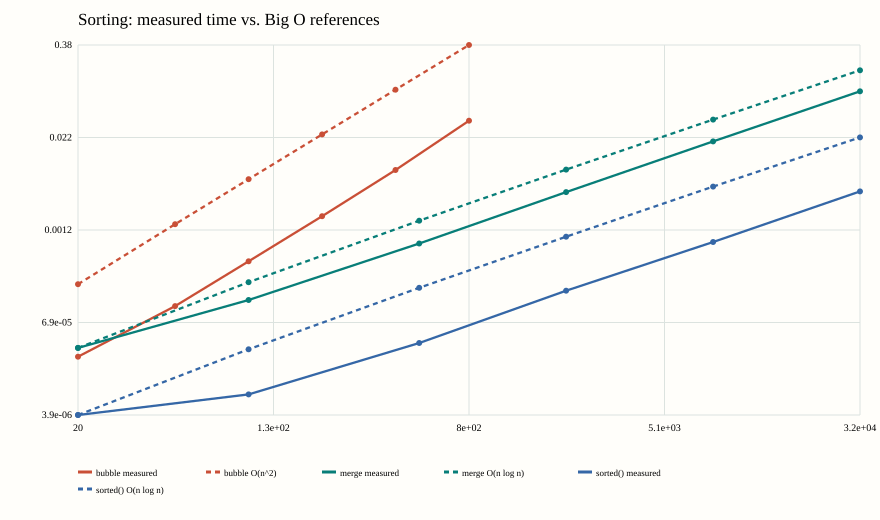

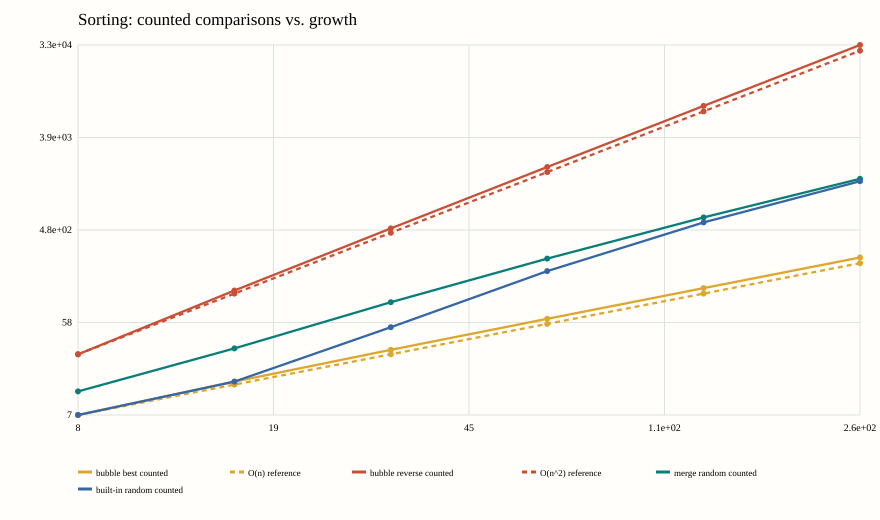

In [5]:
import math
from IPython.display import SVG, display

def log_chart(title, series):
    width, height = 880, 520
    left, right, top, bottom = 78, 20, 45, 105
    xs = [x for item in series for x in item["x"]]
    ys = [y for item in series for y in item["y"] if y > 0]
    x0, x1 = math.log10(min(xs)), math.log10(max(xs))
    y0, y1 = math.log10(min(ys)), math.log10(max(ys))
    pw, ph = width - left - right, height - top - bottom

    def px(x):
        return left + (math.log10(x) - x0) / (x1 - x0) * pw

    def py(y):
        return top + ph - (math.log10(y) - y0) / (y1 - y0) * ph

    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}">']
    parts.append(f'<rect width="100%" height="100%" fill="#fffefa"/><text x="{left}" y="25" font-size="17">{title}</text>')
    for index in range(5):
        fraction = index / 4
        x_value = 10 ** (x0 + fraction * (x1 - x0))
        y_value = 10 ** (y0 + fraction * (y1 - y0))
        x_pos = left + fraction * pw
        y_pos = top + ph - fraction * ph
        parts.append(f'<line x1="{x_pos:.1f}" y1="{top}" x2="{x_pos:.1f}" y2="{top + ph}" stroke="#dce3df"/><line x1="{left}" y1="{y_pos:.1f}" x2="{left + pw}" y2="{y_pos:.1f}" stroke="#dce3df"/>')
        parts.append(f'<text x="{x_pos:.1f}" y="{top + ph + 16}" text-anchor="middle" font-size="10">{x_value:.2g}</text><text x="{left - 6}" y="{y_pos + 3:.1f}" text-anchor="end" font-size="10">{y_value:.2g}</text>')

    legend_x, legend_y = left, height - 48
    for item in series:
        color, dash, label = item["color"], item.get("dash", "none"), item["label"]
        points = " ".join(f"{px(x):.1f},{py(y):.1f}" for x, y in zip(item["x"], item["y"]) if y > 0)
        parts.append(f'<polyline points="{points}" fill="none" stroke="{color}" stroke-width="2.3" stroke-dasharray="{dash}"/>')
        for x, y in zip(item["x"], item["y"]):
            if y > 0:
                parts.append(f'<circle cx="{px(x):.1f}" cy="{py(y):.1f}" r="3" fill="{color}"/>')
        if legend_x + len(label) * 6 + 38 > width - right:
            legend_x, legend_y = left, legend_y + 17
        parts.append(f'<line x1="{legend_x}" y1="{legend_y}" x2="{legend_x + 14}" y2="{legend_y}" stroke="{color}" stroke-width="3" stroke-dasharray="{dash}"/><text x="{legend_x + 18}" y="{legend_y + 4}" font-size="9">{label}</text>')
        legend_x += len(label) * 6 + 38

    parts.append("</svg>")
    return SVG("".join(parts))

bubble_n2 = [n * (n - 1) / 2 for n in bubble_sizes]
merge_nlogn = [n * math.log2(n) for n in fast_sort_sizes]
runtime_series = [
    {"label": "bubble measured", "x": list(bubble_sizes), "y": bubble_times, "color": "#c94f36"},
    {"label": "bubble O(n^2)", "x": list(bubble_sizes), "y": [bubble_times[0] * n / bubble_sizes[0] for n in bubble_n2], "color": "#c94f36", "dash": "5 4"},
    {"label": "merge measured", "x": list(fast_sort_sizes), "y": merge_times, "color": "#087e78"},
    {"label": "merge O(n log n)", "x": list(fast_sort_sizes), "y": [merge_times[0] * value / merge_nlogn[0] for value in merge_nlogn], "color": "#087e78", "dash": "5 4"},
    {"label": "sorted() measured", "x": list(fast_sort_sizes), "y": builtin_times, "color": "#3567a6"},
    {"label": "sorted() O(n log n)", "x": list(fast_sort_sizes), "y": [builtin_times[0] * value / merge_nlogn[0] for value in merge_nlogn], "color": "#3567a6", "dash": "5 4"},
]
display(log_chart("Sorting: measured time vs. Big O references", runtime_series))

count_n = list(count_sizes)
best_counts = [row["bubble best comparisons"] for row in comparison_rows]
worst_counts = [row["bubble reverse comparisons"] for row in comparison_rows]
merge_counts = [row["merge random comparisons"] for row in comparison_rows]
builtin_counts = [row["built-in random comparisons"] for row in comparison_rows]
count_series = [
    {"label": "bubble best counted", "x": count_n, "y": best_counts, "color": "#dda62e"},
    {"label": "O(n) reference", "x": count_n, "y": [best_counts[0] * n / count_n[0] for n in count_n], "color": "#dda62e", "dash": "5 4"},
    {"label": "bubble reverse counted", "x": count_n, "y": worst_counts, "color": "#c94f36"},
    {"label": "O(n^2) reference", "x": count_n, "y": [worst_counts[0] * (n / count_n[0]) ** 2 for n in count_n], "color": "#c94f36", "dash": "5 4"},
    {"label": "merge random counted", "x": count_n, "y": merge_counts, "color": "#087e78"},
    {"label": "built-in random counted", "x": count_n, "y": builtin_counts, "color": "#3567a6"},
]
display(log_chart("Sorting: counted comparisons vs. growth", count_series))

## What the comparison tells us

Bubble sort's early-exit behavior changes its best case, but not its quadratic worst case. Merge sort uses recursion where it fits naturally: sort smaller halves, then combine them. Python's built-in sort usually wins in real programs because it is highly optimized and adapts to existing order. Big O predicts scale; counts reveal the chosen operations; timings include implementation constants, data shape, and runtime effects.

Discuss: why does already sorted input help bubble sort and Timsort? Why does merge sort keep similar growth across input arrangements? What does the native sorter do that the teaching versions omit?